# Day 27 — Support Vector Machines (SVM)
### 3-Hour Beginner ML Class

**Dataset:** Breast Cancer Wisconsin Dataset (built into scikit-learn)

**Agenda:**
1. Load Dataset & Basic EDA
2. Minimal Preprocessing
3. Train-Test Split
4. Feature Scaling
5. SVM Theory — Hyperplane, Margin, Support Vectors, Kernel
6. Train SVM (Linear, RBF, Polynomial kernels)
7. Model Comparison — Accuracy, Precision, Recall, F1-score
8. Confusion Matrix & Classification Report
9. Important SVM Parameters — `C`, `kernel`, `gamma`
10. Practice Section


## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing & split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# Display settings
sns.set(style="whitegrid")
%matplotlib inline


## 2. Load Dataset & Basic EDA

We use the **Breast Cancer Wisconsin dataset** — a classic binary classification
dataset where the goal is to predict whether a tumor is **malignant (0)** or
**benign (1)** based on measurements of cell nuclei.


In [2]:
# Load dataset from sklearn
data = load_breast_cancer()

# Convert to DataFrame for easy exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# Statistical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum().sum())


Missing values per column:
 0


target
1    357
0    212
Name: count, dtype: int64

Class names: {0: 'malignant', 1: 'benign'}


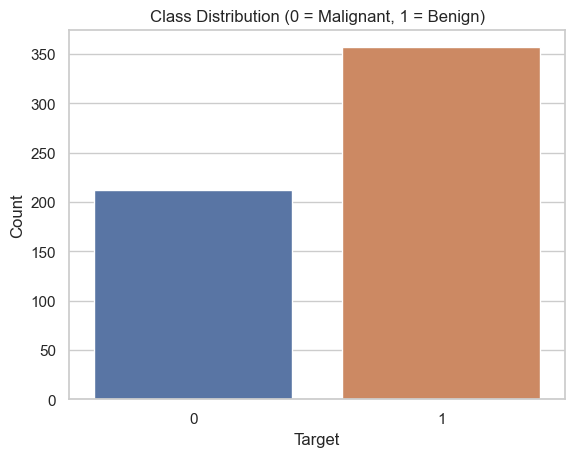

In [6]:
# Class distribution (target balance)
print(df['target'].value_counts())
print("\nClass names:", dict(enumerate(data.target_names)))

sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


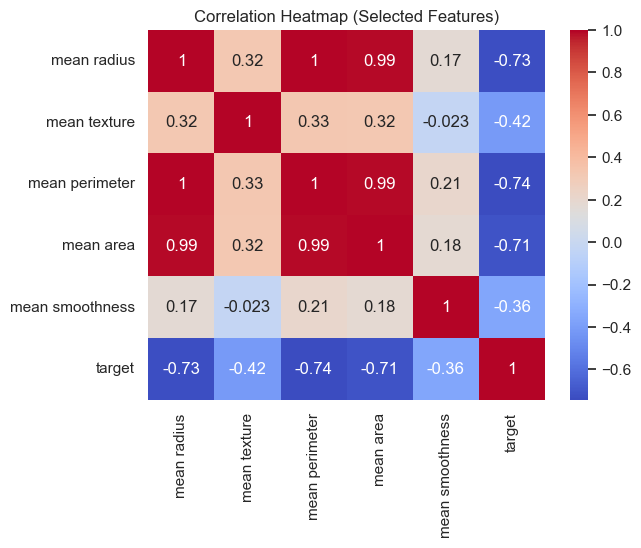

In [7]:
# Quick look at correlation of a few important features with target
important_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
sns.heatmap(df[important_feats + ['target']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Features)")
plt.show()


## 3. Minimal Preprocessing

The Breast Cancer dataset from sklearn is already clean (no missing values,
all numeric). So preprocessing here is minimal — we just separate features (X)
and target (y).


In [8]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (569, 30)
Target shape: (569,)


## 4. Train-Test Split

We split the data into training (80%) and testing (20%) sets.
`stratify=y` ensures both sets keep the same class ratio as the original data.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (455, 30)
Test size : (114, 30)


## 5. Feature Scaling

SVM is **distance-based** (it relies on margins/distances between points),
so features with larger numeric ranges can dominate the decision boundary.
**Feature scaling (standardization) is essential for SVM.**

We fit the scaler only on training data, then transform both train and test sets
(to avoid data leakage).


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)         # only transform on test

print("Mean of scaled training data (should be ~0):", X_train_scaled.mean().round(2))
print("Std of scaled training data (should be ~1):", X_train_scaled.std().round(2))


Mean of scaled training data (should be ~0): -0.0
Std of scaled training data (should be ~1): 1.0


## 6. SVM Theory — Concept, Hyperplane, Margin, Support Vectors, Kernel

**Support Vector Machine (SVM)** is a supervised learning algorithm used for
classification (and regression). Its goal is to find the **best boundary**
that separates classes.

### Key Concepts

- **Hyperplane**: The decision boundary that separates classes.
  In 2D it's a line, in 3D a plane, and in higher dimensions a "hyperplane."

- **Margin**: The distance between the hyperplane and the nearest data points
  of each class. SVM tries to **maximize this margin** — a bigger margin
  usually means better generalization.

- **Support Vectors**: The data points closest to the hyperplane that
  "support" (define) the margin. Only these points matter for the boundary —
  other points don't affect it directly.

- **Kernel Trick**: When data isn't linearly separable, SVM uses a **kernel
  function** to map data into a higher-dimensional space where a linear
  separator *can* be found — without explicitly computing the transformation.
  Common kernels:
  - `linear` — straight-line boundary, best for linearly separable data.
  - `rbf` (Radial Basis Function) — handles non-linear boundaries, most popular default.
  - `poly` (Polynomial) — creates curved boundaries using polynomial combinations of features.

**In short:** SVM finds the hyperplane that best separates classes with the
maximum margin, using only the closest points (support vectors), and can
handle non-linear data using kernels.


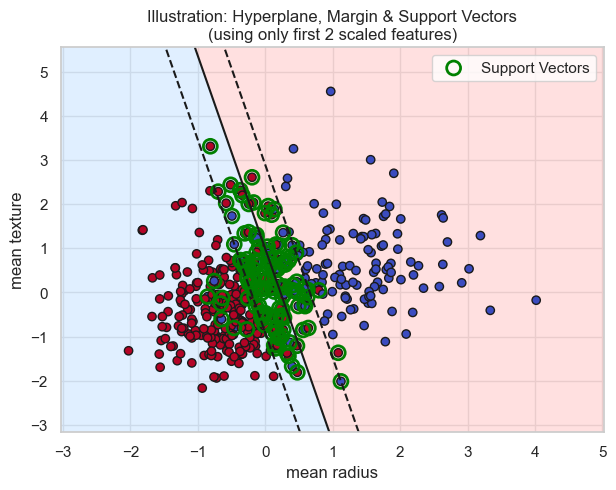

In [11]:
# Simple 2-feature visualization to build intuition about hyperplane & margin
# (For visualization purposes only — uses 2 features, not the full model)

from sklearn.svm import SVC as SVC_demo

X_vis = X_train_scaled[:, [0, 1]]   # first two scaled features
y_vis = y_train.values

demo_model = SVC_demo(kernel='linear', C=1.0)
demo_model.fit(X_vis, y_vis)

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200),
                      np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200))
Z = demo_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, levels=[-1e6, 0, 1e6], colors=['#FFCCCC', '#CCE5FF'], alpha=0.6)
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], linestyles=['--','-','--'])
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, cmap='coolwarm', edgecolors='k')
plt.scatter(demo_model.support_vectors_[:,0], demo_model.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='green', linewidths=2, label='Support Vectors')
plt.title("Illustration: Hyperplane, Margin & Support Vectors\n(using only first 2 scaled features)")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend()
plt.show()


## 7. Train SVM with Different Kernels

We now train the actual SVM models on the **full feature set** using three
kernels: **Linear**, **RBF**, and **Polynomial**.


In [12]:
# Linear kernel
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
pred_linear = svm_linear.predict(X_test_scaled)

# RBF kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
pred_rbf = svm_rbf.predict(X_test_scaled)

# Polynomial kernel
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
svm_poly.fit(X_train_scaled, y_train)
pred_poly = svm_poly.predict(X_test_scaled)

print("All 3 SVM models trained successfully!")


All 3 SVM models trained successfully!


## 8. Compare Models — Accuracy, Precision, Recall, F1-score


In [13]:
def evaluate(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

results = [
    evaluate(y_test, pred_linear, 'Linear Kernel'),
    evaluate(y_test, pred_rbf, 'RBF Kernel'),
    evaluate(y_test, pred_poly, 'Polynomial Kernel')
]

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-score
Model,,,,
Linear Kernel,0.9737,0.9859,0.9722,0.9790
RBF Kernel,0.9825,0.9861,0.9861,0.9861
Polynomial Kernel,0.9123,0.8780,1.0000,0.9351


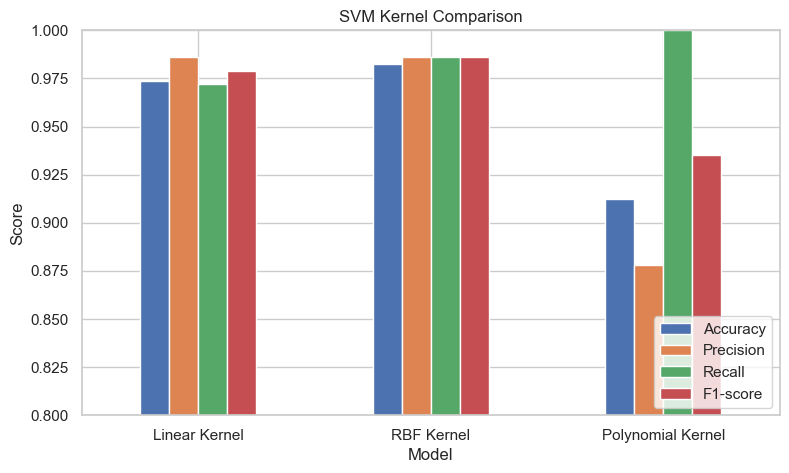

In [14]:
# Visual comparison
results_df.plot(kind='bar', figsize=(9,5))
plt.title("SVM Kernel Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


## 9. Confusion Matrix & Classification Report

Let's look closer at the **best-performing kernel** (based on the comparison above).


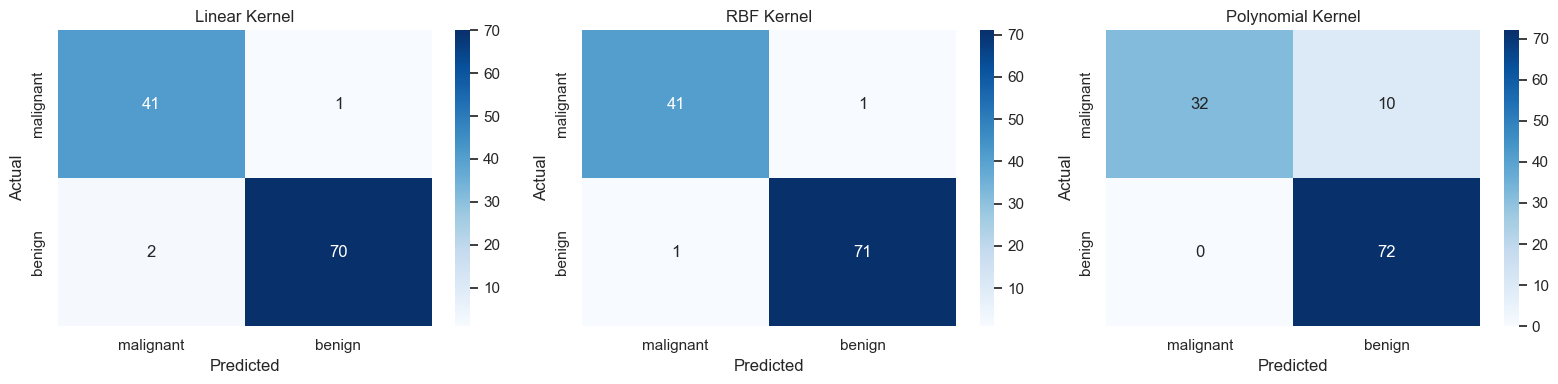

In [15]:
# Confusion matrices for all three kernels
fig, axes = plt.subplots(1, 3, figsize=(16,4))
preds = {'Linear': pred_linear, 'RBF': pred_rbf, 'Polynomial': pred_poly}

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=data.target_names, yticklabels=data.target_names)
    ax.set_title(f"{name} Kernel")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [16]:
# Detailed classification report for each kernel
for name, pred in preds.items():
    print(f"--- {name} Kernel ---")
    print(classification_report(y_test, pred, target_names=data.target_names))
    print()


--- Linear Kernel ---
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- RBF Kernel ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Polynomial Kernel ---
              precision    recall  f1-score   support

   malignant       1.00      0.76      0.86        42
      benign       0.88      1.00      0.94        72

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weigh

## 10. Important SVM Parameters

| Parameter | Meaning |
|---|---|
| **`C`** | Controls the trade-off between a wide margin and classifying training points correctly. Small `C` → wider margin, more tolerant of misclassification (simpler model). Large `C` → narrower margin, tries hard to classify every point correctly (risk of overfitting). |
| **`kernel`** | Defines how the decision boundary is shaped: `'linear'` (straight boundary), `'rbf'` (flexible, non-linear), `'poly'` (polynomial curves). |
| **`gamma`** | Used in `rbf`/`poly` kernels. Controls how much influence a single training point has. Small `gamma` → far-reaching influence (smoother boundary). Large `gamma` → close influence only (boundary fits training points tightly, risk of overfitting). |

**Rule of thumb:** Start with `kernel='rbf'`, `C=1`, `gamma='scale'` (sklearn defaults), then tune using cross-validation.


In [17]:
# Quick demo: effect of different C values with RBF kernel
for c_val in [0.01, 1, 100]:
    model = SVC(kernel='rbf', C=c_val, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"C = {c_val:<6} -> Test Accuracy = {acc:.4f}")


C = 0.01   -> Test Accuracy = 0.6316
C = 1      -> Test Accuracy = 0.9825
C = 100    -> Test Accuracy = 0.9474


## 11. Practice Section

Try these on your own:

1. Train an SVM with `kernel='rbf'` and `gamma=0.001`. Compare its accuracy
   to the model trained with `gamma='scale'`. What do you observe?
2. Change the polynomial kernel's `degree` to `2` and `5`. How does the
   F1-score change?
3. Try `C=0.1` and `C=10` with the linear kernel. Which gives better test accuracy?
4. (Bonus) Which kernel performed best overall on this dataset, and why do
   you think that is, given the nature of the data?


In [18]:
# Write your practice code here
